# Знакомство с `statsmodels`: данные и визуализация

**Курс:** Прогнозирование временных рядов. Вводное занятие.

`statsmodels` — это «академическая» библиотека статистики для Python. Если `scikit-learn`
отвечает на вопрос *«насколько точен мой прогноз?»*, то `statsmodels` отвечает на вопрос
*«как устроены мои данные и можно ли доверять оценкам?»*. Именно поэтому знакомство с
временными рядами удобно начинать с неё: она даёт язык и инструменты для **разведочного
анализа**, а не только модели.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Как устроена библиотека и где что искать |
| 1 | В каком виде `statsmodels` хочет получить временной ряд |
| 2 | Как посмотреть на ряд и что о нём можно узнать |

## Чего здесь сознательно нет

Сегодня мы **смотрим** на данные, но пока не **меняем** их и не строим прогнозы:

* **преобразования ряда** (логарифм, дифференцирование, лаги, детренд) — тема отдельного
  занятия, потому что они нужны как подготовка к моделированию;
* **диагностика моделей и прогнозов** (`plot_predict`, `plot_diagnostics`) — там же,
  вместе с самими моделями.

Эти сюжеты собраны в отдельном ноутбуке `Черновик — преобразования и диагностика.ipynb`.

## Как работать с ноутбуком

Запускайте ячейки последовательно (`Shift+Enter`). Ячейки зависят от предыдущих:
данные загружаются один раз в разделе 1 и используются до конца.

> **Соглашение об оформлении.** Блоки, начинающиеся с 🔍, — это то, на что стоит
> обратить внимание особо: там прячутся типичные ошибки новичков.

---
# 0. Основная концепция библиотеки и её структура

## 0.1. Главная идея: «модель → обучение → результат»

Почти всё в `statsmodels` подчиняется одному сценарию из трёх шагов:

```
model = SomeModel(data, ...)   # 1. ОПИСАНИЕ: что за модель и на каких данных
res   = model.fit()            # 2. ОЦЕНКА:   подобрать параметры
res.summary()                  # 3. РЕЗУЛЬТАТ: посмотреть, что получилось
```

Это отличается от `scikit-learn`, где `.fit()` меняет сам объект модели. Здесь
`.fit()` **возвращает новый объект** — «результаты». Модель остаётся описанием задачи,
а результаты хранят оценки, остатки, стандартные ошибки, тесты и методы прогноза.

Практический вывод: результат `.fit()` нужно обязательно куда-то сохранить,
иначе он потеряется.

Сегодня мы почти не работаем с моделями, но этот шаблон встретим дважды — у
разложения ряда на компоненты (`STL`) он точно такой же.

## 0.2. Словарь: `endog` и `exog`

Два слова, которые встречаются в документации `statsmodels` буквально везде:

| Термин | Полное название | Что это | Аналог в ML |
|---|---|---|---|
| `endog` | эндогенная переменная | то, что мы моделируем и прогнозируем | `y`, таргет |
| `exog` | экзогенные переменные | внешние факторы-регрессоры | `X`, признаки |

«Эндогенная» = объясняемая внутри модели, «экзогенная» = приходящая извне.
Для временного ряда `endog` — это сам ряд (например, число пассажиров по месяцам),
а `exog` — например, признак праздничного дня или цена на топливо.

## 0.3. Структура библиотеки

Для временных рядов нам важны три части:

| Что импортируем | Зачем |
|---|---|
| `statsmodels.api as sm` | общая точка входа: регрессии, датасеты, общая графика |
| `statsmodels.tsa.api as tsa` | **t**ime **s**eries **a**nalysis: модели, тесты, разложения |
| `statsmodels.graphics.tsaplots` | специализированные графики для рядов (ACF, сезонность) |

Внутри `tsa` встречаются три группы объектов:

* **модели** — `AutoReg`, `ARIMA`, `SARIMAX`, `ExponentialSmoothing`, `VAR`, …
* **тесты и характеристики** (`tsa.stattools`) — `acf`, `pacf`, `adfuller`, `kpss`, …
* **разложения и фильтры** (`tsa.seasonal`, `tsa.filters`) — `seasonal_decompose`, `STL`, …

In [1]:
# Стандартный набор импортов для работы с временными рядами в statsmodels.
import warnings
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.tsa.api as tsa

# Чуть более крупные и читаемые графики по умолчанию.
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

print("statsmodels:", sm.__version__)
print("pandas:     ", pd.__version__)
print("numpy:      ", np.__version__)

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/1/.venv/lib/python3.11/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


statsmodels: 0.14.6
pandas:      2.3.3
numpy:       2.4.6


### Как искать нужное, не заглядывая в интернет

`dir()` показывает содержимое модуля. Это самый быстрый способ понять, что вообще
доступно. Ниже — список моделей и функций верхнего уровня из `tsa.api`.

In [2]:
# Всё публичное содержимое tsa.api: то, из чего складывается работа с рядами.
public_api = [name for name in dir(tsa) if not name.startswith("_")]
print(f"Объектов в tsa.api: {len(public_api)}\n")

# Печатаем аккуратными колонками по 4 штуки.
for i in range(0, len(public_api), 4):
    print("".join(f"{name:<28}" for name in public_api[i : i + 4]))

Объектов в tsa.api: 61

AR                          ARDL                        ARIMA                       ArmaProcess                 
AutoReg                     DynamicFactor               DynamicFactorMQ             ETSModel                    
ExponentialSmoothing        Holt                        MarkovAutoregression        MarkovRegression            
SARIMAX                     STL                         STLForecast                 SVAR                        
SimpleExpSmoothing          UECM                        UnobservedComponents        VAR                         
VARMAX                      VECM                        acf                         acovf                       
add_lag                     add_trend                   adfuller                    ardl_select_order           
arima                       arma_generate_sample        arma_order_select_ic        bds                         
bk_filter                   breakvar_heteroskedasticity_testccf         

🔍 Обратите внимание: в этом списке рядом лежат и модели (`ARIMA`, `SARIMAX`, `STL`),
и статистические тесты (`adfuller`, `kpss`), и утилиты (`add_trend`, `lagmat`).
Такая «плоская» организация — особенность `statsmodels`: библиотека собрана вокруг
статистических понятий, а не вокруг пайплайнов.

Документацию по любому объекту можно прочитать прямо в ноутбуке:
`tsa.seasonal_decompose?` или `help(tsa.seasonal_decompose)`.

In [3]:
# Пример: короткая справка по функции прямо из ноутбука.
# Первые строки docstring обычно объясняют суть; полная версия — через help().
print(tsa.seasonal_decompose.__doc__[:700])


    Seasonal decomposition using moving averages.

    Parameters
    ----------
    x : array_like
        Time series. If 2d, individual series are in columns. x must contain 2
        complete cycles.
    model : {"additive", "multiplicative"}, optional
        Type of seasonal component. Abbreviations are accepted.
    filt : array_like, optional
        The filter coefficients for filtering out the seasonal component.
        The concrete moving average method used in filtering is determined by
        two_sided.
    period : int, optional
        Period of the series (e.g., 1 for annual, 4 for quarterly, etc). Must
        be used if x is not a pandas object or if the index of x does 


---
# 1. Формат данных

Здесь находится **главная практическая сложность** для новичка. `statsmodels` не
придумывает свой контейнер для данных (в отличие от `ETNA` с его `TSDataset` или
`sktime` с мульти-индексами). Он работает с обычными объектами `pandas`:

* **`pd.Series`** — один временной ряд (одномерный случай);
* **`pd.DataFrame`** — несколько рядов, каждый в своём столбце (многомерный случай).

Но есть требование к **индексу**: он должен быть временным и, как правило, знать
свою **частоту** (`freq`). Разберёмся, что это значит.

## 1.1. Способ первый: загрузка из CSV

Самый частый случай на практике. Важны два аргумента `pd.read_csv`:

* `parse_dates=[...]` — превратить текст в даты (`datetime64`), а не оставить строками;
* `index_col=...` — сделать столбец с датой индексом.

In [4]:
# Датасет AirPassengers — классика: число авиапассажиров по месяцам, 1949–1960.
air_raw = pd.read_csv(
    "../data/AirPassengers.csv",
    parse_dates=["Month"],   # столбец Month читаем как дату
    index_col="Month",       # и сразу делаем его индексом
)

print("Тип объекта:  ", type(air_raw).__name__)
print("Размер:       ", air_raw.shape)
print("Тип индекса:  ", type(air_raw.index).__name__)
print("Тип значений: ", air_raw["#Passengers"].dtype)
air_raw.head()

Тип объекта:   DataFrame
Размер:        (144, 1)
Тип индекса:   DatetimeIndex
Тип значений:  int64


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Мы получили `DataFrame` с одним столбцом. Для одномерного ряда удобнее работать с
`Series` — обращаемся к столбцу по имени.

In [5]:
# Выделяем одномерный ряд (Series) — с ним будем работать весь ноутбук.
air = air_raw["#Passengers"]

print("Тип:", type(air).__name__)
print("freq индекса:", air.index.freq)   # <- ключевая строка, смотрим ниже

Тип: Series
freq индекса: None


## 1.2. Почему `freq` — самое важное поле

🔍 Выше `air.index.freq` вернул `None`. Даты в индексе есть, они упорядочены и идут
ровно раз в месяц — но `pandas` **не делает выводов автоматически**: он не знает,
что пропусков в календаре нет.

Для `statsmodels` это критично. Многие методы (сезонное разложение, сезонные графики,
сезонные модели) должны знать **длину сезона**: 12 для месячных данных, 4 для
квартальных, 7 для дневных с недельной сезонностью. Эту длину они выводят из `freq`.
Нет `freq` — нет сезонности.

Проверим, что произойдёт при попытке разложить ряд без временного индекса вообще.

In [6]:
# Демонстрация ошибки: ряд с обычной нумерацией 0,1,2,... вместо дат.
air_no_index = air.reset_index(drop=True)   # выбрасываем даты, остаётся RangeIndex
print("Индекс стал:", type(air_no_index.index).__name__)

try:
    tsa.seasonal_decompose(air_no_index)
except ValueError as err:
    print("\nОшибка ValueError:")
    print(" ", err)

Индекс стал: RangeIndex

Ошибка ValueError:
  You must specify a period or x must be a pandas object with a PeriodIndex or a DatetimeIndex with a freq not set to None


Сообщение об ошибке буквально перечисляет три допустимых варианта:
указать `period` вручную, использовать `PeriodIndex`, либо `DatetimeIndex` с непустым
`freq`. Разберём, как получить последнее.

### `asfreq()` vs `resample()` — разные задачи, которые легко спутать

| Метод | Что делает | Когда применять |
|---|---|---|
| `.asfreq(freq)` | **объявляет** сетку; данные не агрегирует, на пропущенных датах ставит `NaN` | шаг данных уже правильный, надо только зафиксировать `freq` |
| `.resample(freq)` | **меняет** шаг; требует агрегации (`.mean()`, `.sum()`) | переход к более крупному шагу: дни → месяцы |

У нас шаг уже месячный, поэтому нужен `asfreq`.

In [7]:
# 'MS' = Month Start, метка периода ставится на первое число месяца.
air = air.asfreq("MS")

print("freq теперь:  ", air.index.freq)
print("Пропусков:    ", int(air.isna().sum()), "— значит, календарь был полным")
print("Период:       ", air.index.min().date(), "—", air.index.max().date())
print("Наблюдений:   ", len(air))

freq теперь:   <MonthBegin>
Пропусков:     0 — значит, календарь был полным
Период:        1949-01-01 — 1960-12-01
Наблюдений:    144


🔍 Если бы после `asfreq` появились `NaN`, это был бы сигнал: в исходных данных
**пропущены даты**. Очень полезная бесплатная проверка качества данных.

Полезно знать, что `statsmodels` умеет сам переводить `freq` в длину сезона —
именно так сезонные методы понимают, чего ожидать.

In [8]:
# freq_to_period: строковая частота -> число наблюдений в году (длина сезона).
from statsmodels.tsa.tsatools import freq_to_period

for f in ["MS", "QS", "W", "D", "YS"]:
    print(f"freq = {f:<4} -> период сезонности = {freq_to_period(f)}")

freq = MS   -> период сезонности = 12
freq = QS   -> период сезонности = 4
freq = W    -> период сезонности = 52
freq = D    -> период сезонности = 7
freq = YS   -> период сезонности = 1


## 1.3. `DatetimeIndex` или `PeriodIndex`?

Два способа представить время, и оба поддерживаются:

* **`DatetimeIndex`** — индекс из *моментов* времени («1949-01-01 00:00:00»).
  Универсален, используется чаще всего.
* **`PeriodIndex`** — индекс из *интервалов* («январь 1949», «1959Q1»).
  Честнее по смыслу: значение относится ко всему месяцу, а не к его первой секунде.
  Удобен для квартальных данных и экономической статистики.

Переходы между ними: `.to_period()` и `.to_timestamp()`.

In [9]:
# Один и тот же ряд в двух представлениях времени.
air_period = air.to_period("M")

print("DatetimeIndex:", air.index[:3].tolist())
print("PeriodIndex:  ", air_period.index[:3].tolist())
print()
print("Обратно в моменты:", air_period.to_timestamp().index[:3].tolist())
print()
print("У PeriodIndex частота всегда задана:", air_period.index.freqstr)

DatetimeIndex: [Timestamp('1949-01-01 00:00:00'), Timestamp('1949-02-01 00:00:00'), Timestamp('1949-03-01 00:00:00')]
PeriodIndex:   [Period('1949-01', 'M'), Period('1949-02', 'M'), Period('1949-03', 'M')]

Обратно в моменты: [Timestamp('1949-01-01 00:00:00'), Timestamp('1949-02-01 00:00:00'), Timestamp('1949-03-01 00:00:00')]

У PeriodIndex частота всегда задана: M


## 1.4. Способ второй: встроенные датасеты

В `statsmodels` вшито около трёх десятков учебных наборов данных — удобно для
экспериментов и воспроизводимых примеров: ничего не нужно скачивать.

Схема доступа одинакова для всех: `sm.datasets.<имя>.load_pandas().data`.

In [10]:
# Список встроенных датасетов.
builtin = [
    name for name in dir(sm.datasets)
    if not name.startswith("_")
    and name not in {"PytestTester", "test", "utils", "check_internet",
                     "clear_data_home", "get_data_home", "get_rdataset", "webuse"}
]
print(f"Встроенных датасетов: {len(builtin)}\n")
for i in range(0, len(builtin), 5):
    print("".join(f"{n:<20}" for n in builtin[i : i + 5]))

Встроенных датасетов: 28

anes96              cancer              ccard               china_smoking       co2                 
committee           copper              cpunish             danish_data         elnino              
engel               fair                fertility           grunfeld            heart               
interest_inflation  longley             macrodata           modechoice          nile                
randhie             scotland            spector             stackloss           star98              
statecrime          strikes             sunspots            


Возьмём три из них — это разные типичные ситуации с форматом данных.

**Случай А: даты уже в индексе.** Датасет `co2` — концентрация CO₂, недельные измерения.

In [11]:
# co2: load_pandas() уже возвращает DataFrame с DatetimeIndex.
co2 = sm.datasets.co2.load_pandas().data

print("Индекс:  ", type(co2.index).__name__)
print("freq:    ", co2.index.freq, "(W-SAT = недели, метка на субботу)")
print("Размер:  ", co2.shape)
print("Пропуски:", int(co2["co2"].isna().sum()), "<- в реальных данных они бывают!")
co2.head()

Индекс:   DatetimeIndex
freq:     <Week: weekday=5> (W-SAT = недели, метка на субботу)
Размер:   (2284, 1)
Пропуски: 59 <- в реальных данных они бывают!


,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


🔍 59 пропусков — хороший повод обсудить: временной ряд с дырами нельзя просто
«выбросить строки» (`dropna()`), потому что это ломает равномерность сетки, а с ней
и понятие лага. Пропуски **интерполируют**, сохраняя длину ряда.

In [12]:
# Корректная обработка пропусков в ряду: интерполяция по времени, а не удаление строк.
co2_series = co2["co2"]
co2_filled = co2_series.interpolate(method="time")

print("до интерполяции: длина", len(co2_series), ", пропусков", int(co2_series.isna().sum()))
print("после:           длина", len(co2_filled), ", пропусков", int(co2_filled.isna().sum()))
print("\nСравните с ошибочным подходом:")
print("dropna():        длина", len(co2_series.dropna()), "- сетка стала неравномерной!")

до интерполяции: длина 2284 , пропусков 59
после:           длина 2284 , пропусков 0

Сравните с ошибочным подходом:
dropna():        длина 2225 - сетка стала неравномерной!


**Случай Б: год отдельным столбцом.** Датасет `nile` — годовой сток реки Нил.
Здесь индекс нужно собрать самостоятельно.

In [13]:
# nile: год лежит в столбце 'year', индекса нет — делаем его сами.
nile_raw = sm.datasets.nile.load_pandas().data
print("Как загрузилось:")
print(nile_raw.head(3))

# Собираем годовой DatetimeIndex: 'YS' = Year Start.
nile = pd.Series(
    nile_raw["volume"].values,
    index=pd.date_range(start=f"{int(nile_raw['year'].iloc[0])}-01-01",
                        periods=len(nile_raw), freq="YS"),
    name="nile",
)
print("\nПосле сборки индекса:")
print(nile.head(3))
print("\nfreq:", nile.index.freq)

Как загрузилось:
     year  volume
0  1871.0  1120.0
1  1872.0  1160.0
2  1873.0   963.0

После сборки индекса:
1871-01-01    1120.0
1872-01-01    1160.0
1873-01-01     963.0
Freq: YS-JAN, Name: nile, dtype: float64

freq: <YearBegin: month=1>


**Случай В: многомерный ряд.** Датасет `macrodata` — макроэкономика США по кварталам.
Столбцы `year` и `quarter` вместе кодируют дату.

In [14]:
# macrodata: несколько рядов сразу -> это DataFrame, каждый столбец = отдельный ряд.
macro = sm.datasets.macrodata.load_pandas().data
print("Столбцов (рядов):", macro.shape[1], "| Наблюдений:", macro.shape[0])
print("Столбцы:", list(macro.columns))
macro[["year", "quarter", "realgdp", "unemp", "infl"]].head(3)

Столбцов (рядов): 14 | Наблюдений: 203
Столбцы: ['year', 'quarter', 'realgdp', 'realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']


,year,quarter,realgdp,unemp,infl
0,1959.0,1.0,2710.349,5.8,0.00
1,1959.0,2.0,2778.801,5.1,2.34
2,1959.0,3.0,2775.488,5.3,2.74


In [15]:
# Для квартальных данных PeriodIndex особенно нагляден: '1959Q1' вместо '1959-01-01'.
macro.index = pd.period_range(start="1959Q1", periods=len(macro), freq="Q")
macro = macro.drop(columns=["year", "quarter"])   # даты теперь в индексе, столбцы лишние

print("Индекс:", macro.index[:4].tolist())
macro[["realgdp", "unemp", "infl"]].head(3)

Индекс: [Period('1959Q1', 'Q-DEC'), Period('1959Q2', 'Q-DEC'), Period('1959Q3', 'Q-DEC'), Period('1959Q4', 'Q-DEC')]


,realgdp,unemp,infl
1959Q1,2710.349,5.8,0.00
1959Q2,2778.801,5.1,2.34
1959Q3,2775.488,5.3,2.74


## 1.5. Способ третий: датасеты R (нужен интернет)

`sm.datasets.get_rdataset()` скачивает любой набор из коллекции R — это сотни
наборов, в том числе почти все классические ряды. Полезно знать о такой возможности,
но на семинаре аккуратно оборачиваем в `try`, чтобы ноутбук работал и без сети.

In [16]:
# get_rdataset(имя, пакет) -> объект с полями .data (DataFrame) и .__doc__ (описание).
try:
    rds = sm.datasets.get_rdataset("AirPassengers", "datasets")
    print("Загружено из R:", rds.data.shape)
    print(rds.data.head(3))
except Exception as err:
    print(f"Нет доступа к сети ({type(err).__name__}) — пропускаем, это нормально.")

Загружено из R: (144, 2)
          time  value
0  1949.000000    112
1  1949.083333    118
2  1949.166667    132


## 1.6. Итог по формату данных

**Чек-лист перед любым анализом ряда в `statsmodels`:**

1. Данные — это `pd.Series` (один ряд) или `pd.DataFrame` (несколько).
2. Индекс — `DatetimeIndex` или `PeriodIndex`, **отсортированный**.
3. У индекса задан `freq` (проверить: `s.index.freq is not None`).
4. Значения числовые (`float`/`int`), пропуски обработаны интерполяцией.

Мини-функция для такой проверки — полезная привычка.

In [17]:
def check_ts(s: pd.Series, name: str = "ряд") -> None:
    """Быстрая диагностика: готов ли ряд к анализу в statsmodels."""
    ok = "✓"
    no = "✗"
    is_time = isinstance(s.index, (pd.DatetimeIndex, pd.PeriodIndex))
    has_freq = getattr(s.index, "freq", None) is not None
    sorted_ok = s.index.is_monotonic_increasing
    numeric = pd.api.types.is_numeric_dtype(s)
    n_nan = int(s.isna().sum())

    print(f"— {name} —")
    print(f"  {ok if is_time else no} временной индекс ({type(s.index).__name__})")
    print(f"  {ok if has_freq else no} freq = {getattr(s.index, 'freq', None)}")
    print(f"  {ok if sorted_ok else no} отсортирован по времени")
    print(f"  {ok if numeric else no} числовые значения ({s.dtype})")
    print(f"  {ok if n_nan == 0 else no} пропусков: {n_nan}")


check_ts(air, "AirPassengers")
print()
check_ts(co2_series, "CO2 (до интерполяции)")

— AirPassengers —
  ✓ временной индекс (DatetimeIndex)
  ✓ freq = <MonthBegin>
  ✓ отсортирован по времени
  ✓ числовые значения (int64)
  ✓ пропусков: 0

— CO2 (до интерполяции) —
  ✓ временной индекс (DatetimeIndex)
  ✓ freq = <Week: weekday=5>
  ✓ отсортирован по времени
  ✓ числовые значения (float64)
  ✗ пропусков: 59


---
# 2. Встроенные методы визуализации и анализа данных

Данные загружены — можно смотреть. У `statsmodels` есть готовые инструменты, которых
нет ни в `pandas`, ни в `matplotlib`, и они отвечают на конкретные вопросы о ряде:

| Вопрос о ряде | Инструмент |
|---|---|
| Похоже ли настоящее на прошлое? | `acf` / `pacf`, `plot_acf` / `plot_pacf` |
| Есть ли сезонность и в каком месяце пик? | `month_plot`, `quarter_plot`, `seasonal_plot` |
| Из чего состоит ряд? | `seasonal_decompose`, `STL` + их `.plot()` |
| Постоянны ли свойства ряда во времени? | `adfuller`, `kpss` |
| Связаны ли два ряда и кто кого опережает? | `plot_ccf`, `plot_accf_grid` |

**Единое соглашение графических функций:**

* функция **возвращает** объект `Figure`;
* можно передать `ax=` и рисовать в свою сетку подграфиков — так собираются
  составные панели.

🔍 Из-за того, что функция возвращает `Figure`, вызов в конце ячейки Jupyter
нередко рисует график **дважды**. Лечится присваиванием: `fig = plot_acf(...)`
или точкой с запятой на конце.

In [18]:
from statsmodels.graphics.tsaplots import (
    plot_acf,        # коррелограмма (ACF)
    plot_pacf,       # частная автокорреляция (PACF)
    month_plot,      # сезонный график по месяцам
    quarter_plot,    # сезонный график по кварталам
    seasonal_plot,   # общий сезонный график
    plot_ccf,        # кросс-корреляция двух рядов
    plot_accf_grid,  # сетка авто- и кросс-корреляций
)

print("Графические функции для рядов загружены.")

Графические функции для рядов загружены.


## 2.1. С чего начинается любой анализ: просто посмотреть на ряд

Прежде чем считать статистики, ряд рисуют. Здесь достаточно средств `pandas`, но
именно этот график задаёт все дальнейшие вопросы.

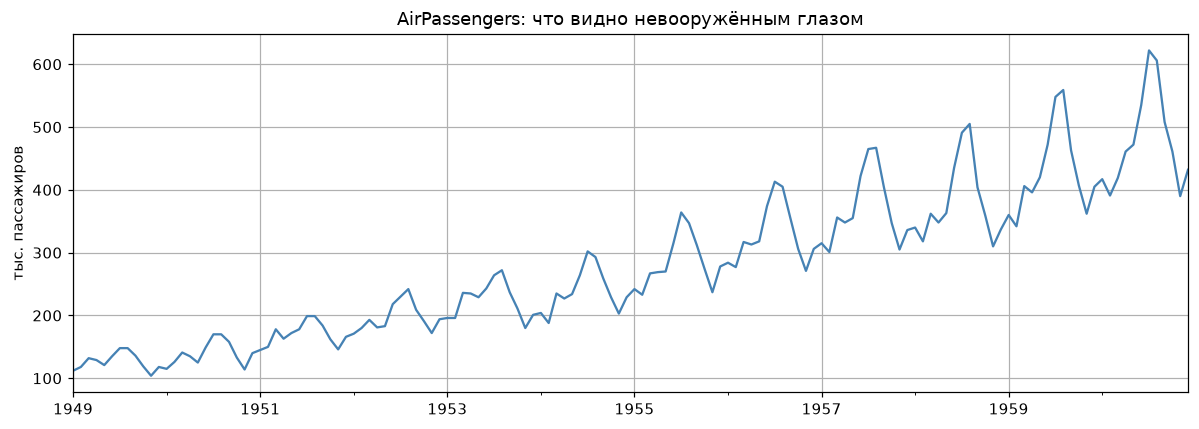

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
air.plot(ax=ax, color="steelblue")
ax.set_title("AirPassengers: что видно невооружённым глазом")
ax.set_ylabel("тыс. пассажиров")
ax.set_xlabel("")
fig.tight_layout()

Три наблюдения, которые мы теперь будем проверять инструментами:

1. **уровень растёт** — есть тренд;
2. **есть регулярные зубцы** — похоже на сезонность с периодом год;
3. **амплитуда зубцов растёт вместе с уровнем** — сезонность мультипликативная.

## 2.2. Автокорреляция: числа и коррелограмма

**Автокорреляция** $r_k$ — корреляция ряда с самим собой, сдвинутым на $k$ шагов.
Отвечает на вопрос «насколько прошлое похоже на настоящее».

Сначала — числа. `acf` даёт полную автокорреляцию, `pacf` — частную (очищенную от
влияния промежуточных лагов).

In [20]:
from statsmodels.tsa.stattools import acf, pacf

acf_values = acf(air, nlags=13)
pacf_values = pacf(air, nlags=13)

table = pd.DataFrame({"ACF": acf_values, "PACF": pacf_values})
table.index.name = "лаг"
print(table.round(3).to_string())
print(f"\nЛаг 1  (месяц назад): ACF = {acf_values[1]:.3f}")
print(f"Лаг 12 (год назад):   ACF = {acf_values[12]:.3f} <- сильная сезонная связь")

       ACF   PACF
лаг              
0    1.000  1.000
1    0.948  0.955
2    0.876 -0.265
3    0.807  0.055
4    0.753  0.109
5    0.714  0.081
6    0.682  0.004
7    0.663  0.156
8    0.656  0.104
9    0.671  0.289
10   0.703  0.207
11   0.743  0.241
12   0.760 -0.158
13   0.713 -0.718

Лаг 1  (месяц назад): ACF = 0.948
Лаг 12 (год назад):   ACF = 0.760 <- сильная сезонная связь


Те же числа в виде графика читаются гораздо быстрее. Как читать коррелограмму:

* **столбики** — значения автокорреляции для каждого лага;
* **синяя полоса** — доверительный интервал для нулевой автокорреляции
  (примерно $\pm 1.96/\sqrt{n}$). Столбик внутри полосы — корреляция статистически
  незначима, её можно считать случайной.

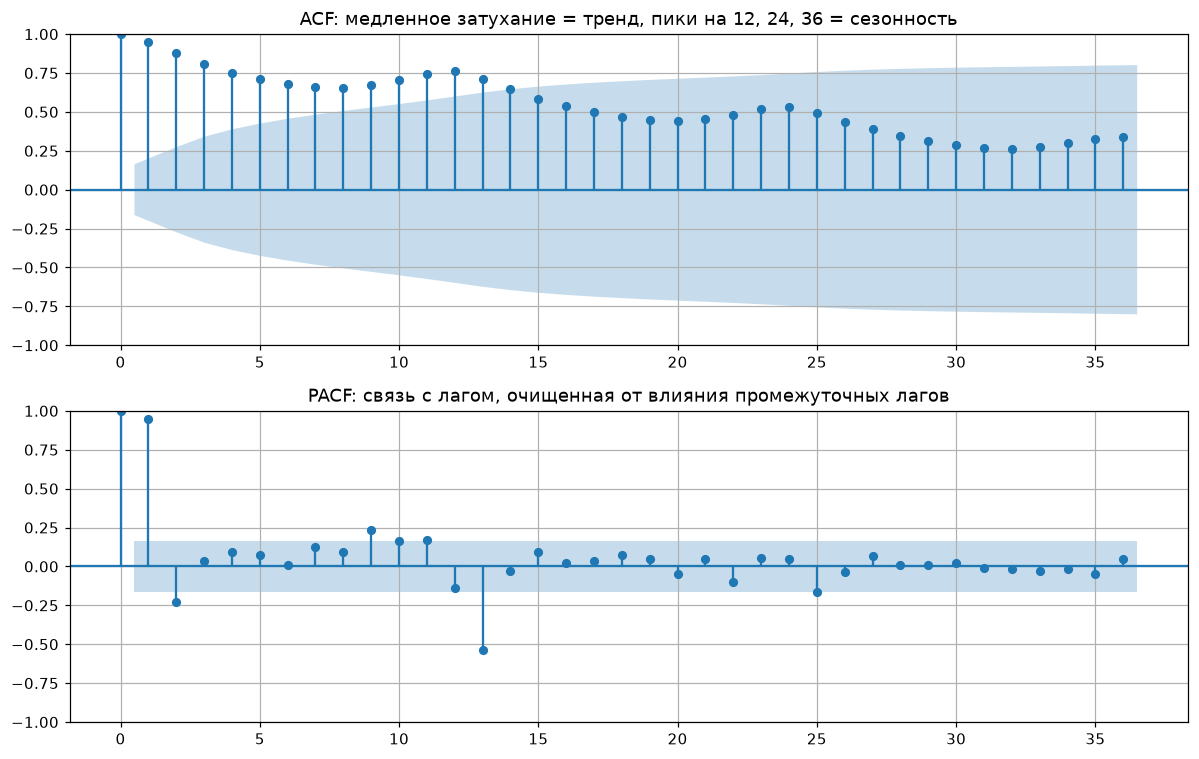

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

plot_acf(air, lags=36, ax=axes[0])
axes[0].set_title("ACF: медленное затухание = тренд, пики на 12, 24, 36 = сезонность")

plot_pacf(air, lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF: связь с лагом, очищенная от влияния промежуточных лагов")

fig.tight_layout()

## 2.3. Белый шум — эталон отсутствия структуры

Чтобы понимать, как выглядит «есть структура», нужно увидеть, как выглядит
«структуры нет». **Белый шум** — независимые одинаково распределённые величины,
ряд без всякой памяти о прошлом.

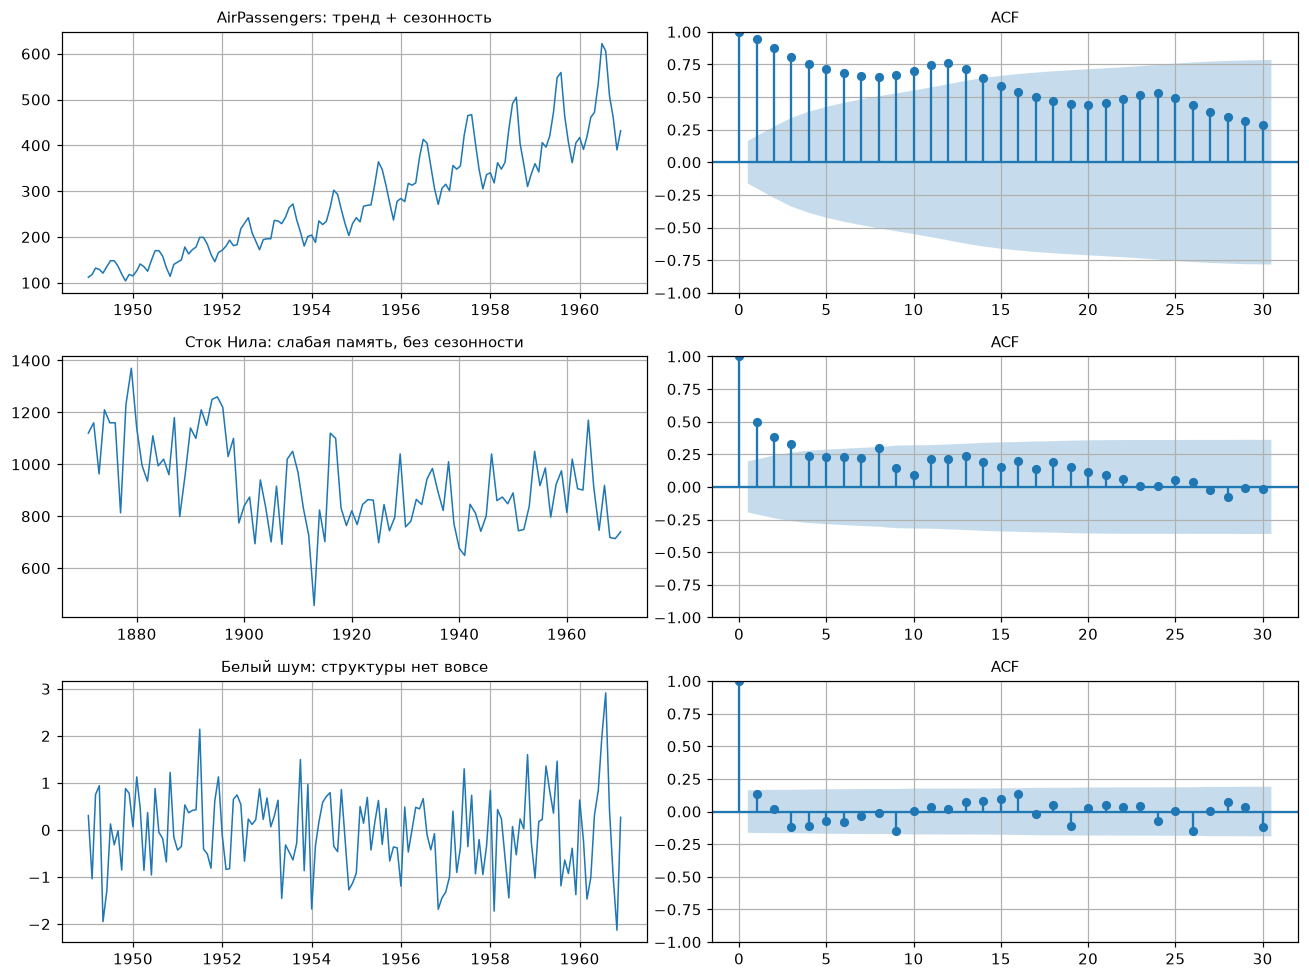

In [22]:
# Генерируем белый шум (seed фиксируем для воспроизводимости) и сравниваем три ряда.
rng = np.random.default_rng(42)
white_noise = pd.Series(rng.normal(size=len(air)), index=air.index, name="white noise")

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

for row, (data, title) in enumerate([
    (air, "AirPassengers: тренд + сезонность"),
    (nile, "Сток Нила: слабая память, без сезонности"),
    (white_noise, "Белый шум: структуры нет вовсе"),
]):
    axes[row, 0].plot(data, lw=1)
    axes[row, 0].set_title(title, fontsize=10)
    plot_acf(data, lags=30, ax=axes[row, 1])
    axes[row, 1].set_title("ACF", fontsize=10)

fig.tight_layout()

🔍 Сравните три коррелограммы справа — это три разных «портрета» ряда:

| Ряд | ACF | Вывод |
|---|---|---|
| AirPassengers | затухает медленно, пики на 12/24/36 | тренд + годовая сезонность |
| Сток Нила | значим лишь первый лаг-два | короткая память, сезонности нет |
| Белый шум | почти всё внутри синей полосы | предсказывать нечего |

Нижняя строка — тот самый эталон. К нему мы вернёмся позже в курсе: если ACF
**остатков модели** выглядит как белый шум, значит модель извлекла из данных
всю структуру. Это стандартная проверка качества прогноза.

## 2.4. Сезонные графики: `month_plot` и `quarter_plot`

Идея: перегруппировать данные не по времени, а **по сезону**. Все январи рядом,
все феврали рядом, и так далее. Внутри каждой группы точки идут по годам,
а красная горизонтальная линия — среднее по группе.

Такой график отвечает на вопросы, невидимые на обычном графике: в каком месяце
пик, стабилен ли он, растёт ли сезонная амплитуда.

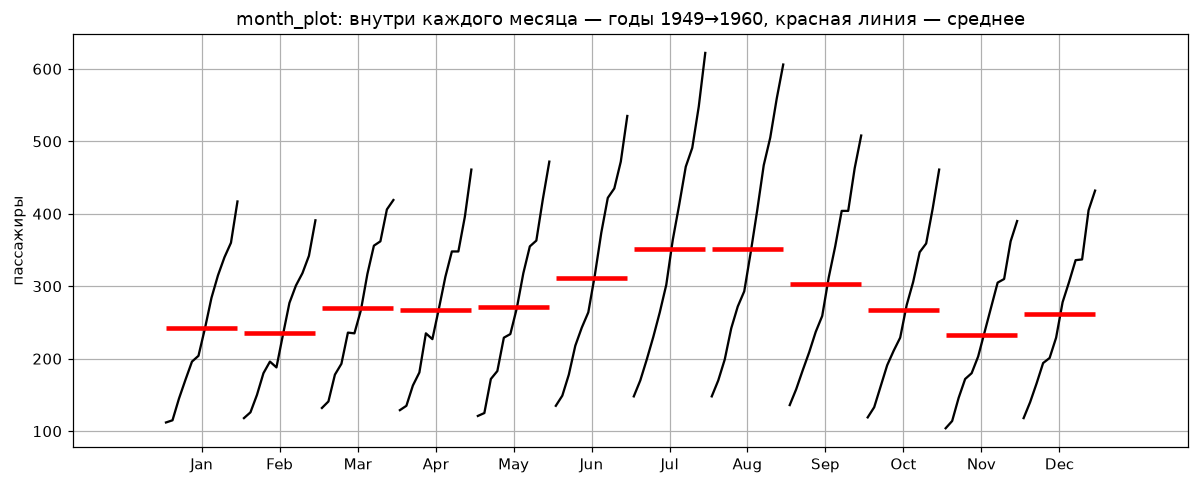

In [23]:
fig, ax = plt.subplots(figsize=(11, 4.5))
month_plot(air, ax=ax)
ax.set_title("month_plot: внутри каждого месяца — годы 1949→1960, красная линия — среднее")
ax.set_ylabel("пассажиры")
fig.tight_layout()

Читаем график: пик приходится на **июль–август**, минимум на **ноябрь**, и внутри
каждого месяца линия растёт слева направо — это тот самый общий тренд.

Для квартальных данных есть парная функция `quarter_plot`.

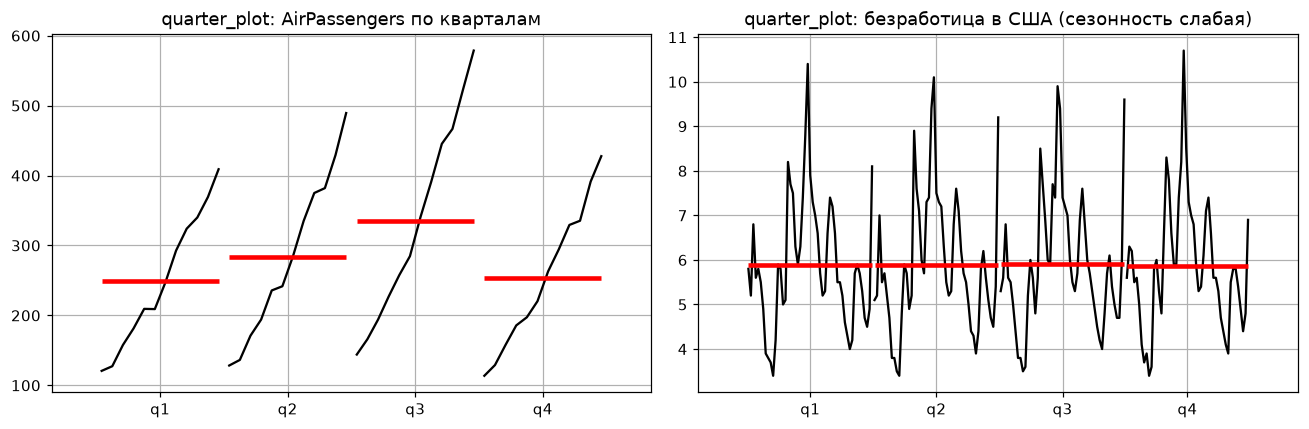

In [24]:
# Приводим месячный ряд к кварталам и строим квартальный сезонный график.
air_quarterly = air.resample("QS").mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

quarter_plot(air_quarterly, ax=axes[0])
axes[0].set_title("quarter_plot: AirPassengers по кварталам")

quarter_plot(macro["unemp"], ax=axes[1])
axes[1].set_title("quarter_plot: безработица в США (сезонность слабая)")

fig.tight_layout()

🔍 Сравните две панели. Слева видна отчётливая сезонность (Q3 заметно выше
остальных). Справа средние по кварталам почти совпадают — у безработицы в этих
данных сезонности практически нет. Так этот график и используют: как быстрый
ответ на вопрос «а есть ли вообще сезонность?».

### `seasonal_plot`: когда нужна нестандартная группировка

`month_plot` и `quarter_plot` — удобные обёртки для частых случаев. Общая функция
`seasonal_plot` позволяет задать сезон самостоятельно: например, день недели или час.
Ей передают результат `groupby` и подписи групп.

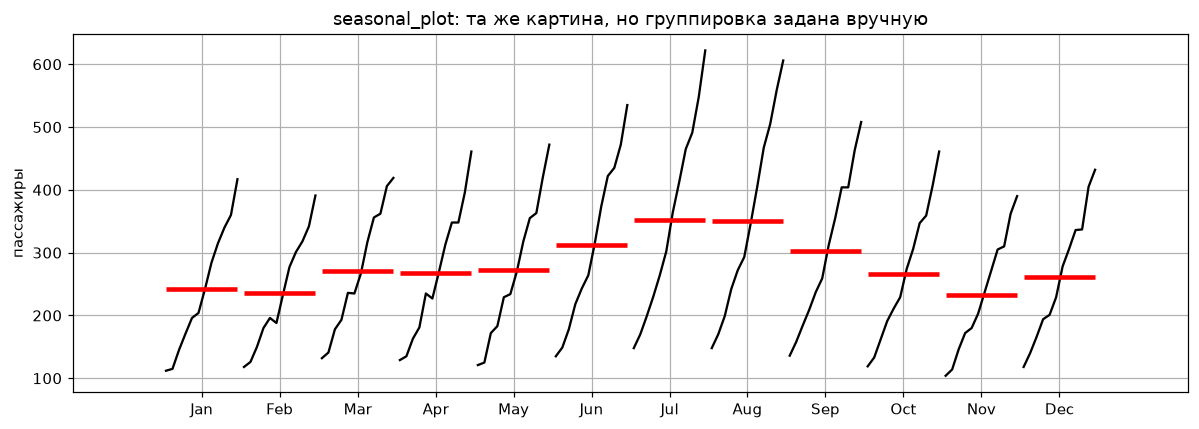

In [25]:
# Группируем по месяцу и передаём подписи вручную -- эквивалент month_plot,
# но так же можно группировать по дню недели, часу и т.п.
fig, ax = plt.subplots(figsize=(11, 4))
seasonal_plot(
    air.groupby(air.index.month),
    xticklabels=[calendar.month_abbr[m] for m in range(1, 13)],
    ylabel="пассажиры",
    ax=ax,
)
ax.set_title("seasonal_plot: та же картина, но группировка задана вручную")
fig.tight_layout()

## 2.5. Из чего состоит ряд: разложение на компоненты

Самый наглядный способ описать ряд — разбить его на **тренд**, **сезонность** и
**остаток**. Две модели разложения:

* **аддитивная**: $y_t = T_t + S_t + R_t$ — амплитуда сезонности постоянна;
* **мультипликативная**: $y_t = T_t \times S_t \times R_t$ — амплитуда растёт с уровнем.

Для AirPassengers по графику из 2.1 очевидно нужна мультипликативная.

🔍 Разложение — на границе «анализа» и «преобразования». Здесь мы используем его
как **описательный** инструмент: посмотреть, что внутри ряда. Как способ *убрать*
сезонность перед моделированием он разбирается на занятии про преобразования.

In [26]:
# seasonal_decompose: классическое разложение скользящими средними.
decomposition = tsa.seasonal_decompose(air, model="multiplicative")

print("Тип результата:", type(decomposition).__name__)
print("Доступные компоненты: .observed, .trend, .seasonal, .resid\n")

# Компоненты — обычные pd.Series с тем же индексом.
components = pd.DataFrame({
    "наблюдения": decomposition.observed,
    "тренд": decomposition.trend,
    "сезонность": decomposition.seasonal,
    "остаток": decomposition.resid,
})
components.head(8).round(3)

Тип результата: DecomposeResult
Доступные компоненты: .observed, .trend, .seasonal, .resid



,наблюдения,тренд,сезонность,остаток
Month,,,,
1949-01-01,112.0,NaN,0.910,NaN
1949-02-01,118.0,NaN,0.884,NaN
1949-03-01,132.0,NaN,1.007,NaN
1949-04-01,129.0,NaN,0.976,NaN
1949-05-01,121.0,NaN,0.981,NaN
1949-06-01,135.0,NaN,1.113,NaN
1949-07-01,148.0,126.792,1.227,0.952
1949-08-01,148.0,127.250,1.220,0.953


🔍 `NaN` в начале столбца «тренд» — не ошибка. Тренд считается центрированным
скользящим средним по 12 месяцам, поэтому для первых и последних 6 точек его
посчитать невозможно. Это фундаментальное свойство метода.

### Результаты умеют себя рисовать

У объекта `DecomposeResult` есть собственный метод `.plot()` — он сразу строит
четырёхпанельную картинку. Это ещё одна иллюстрация общего стиля `statsmodels`.

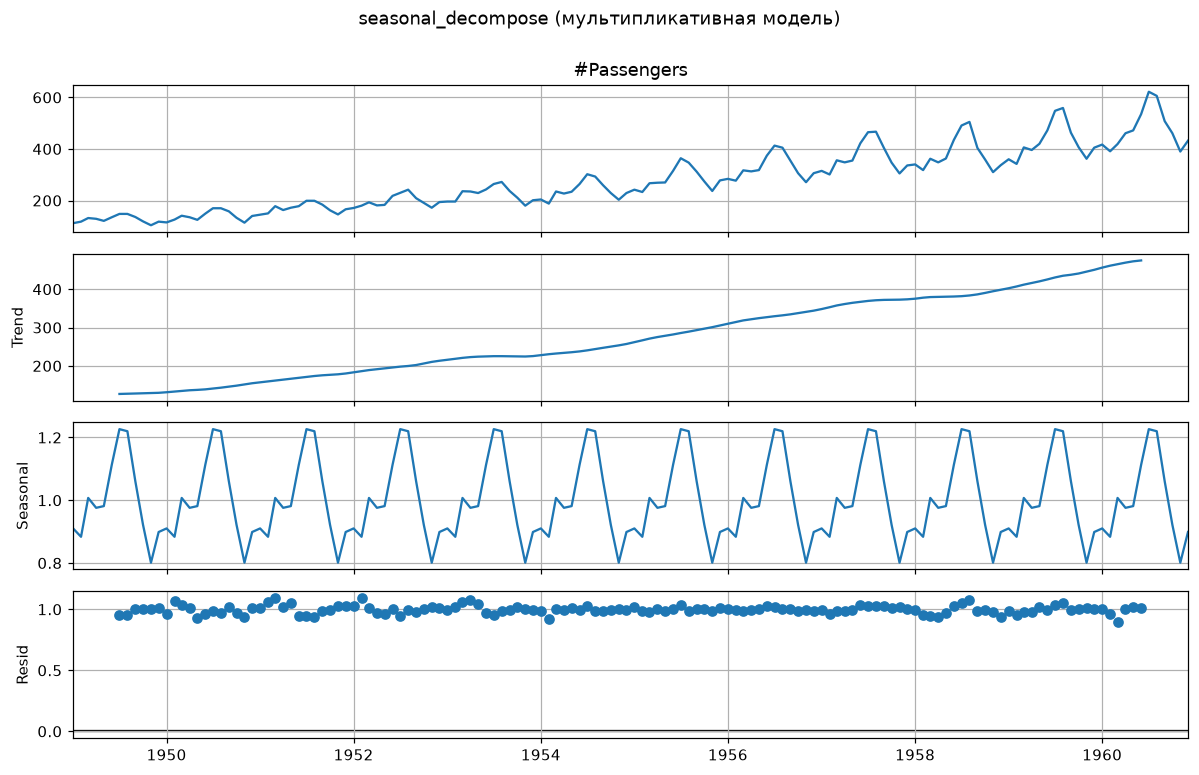

In [27]:
# Одна строка кода -> четыре панели: наблюдения, тренд, сезонность, остаток.
fig = decomposition.plot()
fig.set_size_inches(11, 7)
fig.suptitle("seasonal_decompose (мультипликативная модель)", y=1.00)
fig.tight_layout()

Сезонную компоненту полезно посмотреть и в виде таблицы: это «профиль года».

In [28]:
# Сезонный профиль: множители по месяцам. Значение 1.0 = средний уровень.
seasonal_profile = decomposition.seasonal.groupby(decomposition.seasonal.index.month).first()
seasonal_profile.index = [calendar.month_abbr[m] for m in seasonal_profile.index]

print("Сезонные множители по месяцам:\n")
print(seasonal_profile.round(3).to_string())
print(f"\nПик:  {seasonal_profile.idxmax()} (+{(seasonal_profile.max() - 1) * 100:.0f}% к среднему)")
print(f"Спад: {seasonal_profile.idxmin()} ({(seasonal_profile.min() - 1) * 100:.0f}% к среднему)")

Сезонные множители по месяцам:

Jan    0.910
Feb    0.884
Mar    1.007
Apr    0.976
May    0.981
Jun    1.113
Jul    1.227
Aug    1.220
Sep    1.060
Oct    0.922
Nov    0.801
Dec    0.899

Пик:  Jul (+23% к среднему)
Спад: Nov (-20% к среднему)


### `STL` — современная альтернатива

`STL` (Seasonal-Trend decomposition using LOESS) гибче классического разложения:
сезонность может медленно меняться со временем, метод устойчив к выбросам и не
теряет точки на концах ряда.

Обратите внимание на интерфейс — это ровно тот сценарий «модель → `.fit()` → результат»
из раздела 0.

Тип результата: DecomposeResult
Пропусков в остатке: 0 <- в отличие от seasonal_decompose, концы ряда не теряются


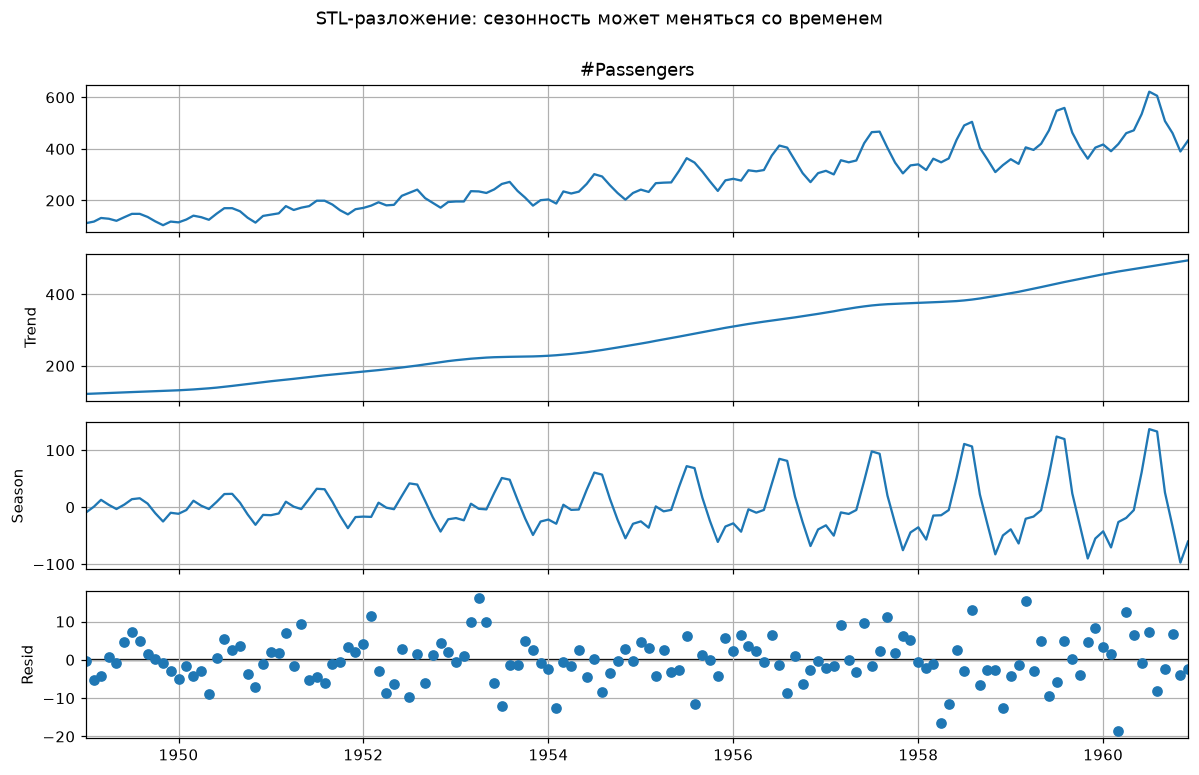

In [29]:
# seasonal=13 - длина окна сглаживания сезонности (нечётное, больше периода).
stl_result = tsa.STL(air, seasonal=13).fit()

print("Тип результата:", type(stl_result).__name__)
print("Пропусков в остатке:", int(pd.Series(stl_result.resid).isna().sum()),
      "<- в отличие от seasonal_decompose, концы ряда не теряются")

fig = stl_result.plot()
fig.set_size_inches(11, 7)
fig.suptitle("STL-разложение: сезонность может меняться со временем", y=1.00)
fig.tight_layout()

## 2.6. Постоянны ли свойства ряда: тесты на стационарность

**Стационарный** ряд — тот, у которого статистические свойства (среднее, дисперсия)
не меняются во времени. Это ключевое требование большинства классических моделей,
поэтому проверять стационарность приходится постоянно.

Два теста с **противоположными** нулевыми гипотезами — их удобно применять вместе:

| Тест | $H_0$ | Малое p-value означает |
|---|---|---|
| **ADF** (Дики–Фуллера) | ряд **нестационарен** | ряд стационарен ✓ |
| **KPSS** | ряд **стационарен** | ряд нестационарен ✗ |

🔍 Самая частая ошибка — перепутать направление. Запомните: у ADF и KPSS гипотезы
зеркальные, поэтому «хороший» результат выглядит по-разному.

In [30]:
from statsmodels.tsa.stattools import adfuller, kpss


def stationarity_report(series: pd.Series, name: str) -> None:
    """Применяем ADF и KPSS и переводим результат на человеческий язык."""
    s = series.dropna()

    adf_stat, adf_p = adfuller(s)[:2]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")          # KPSS предупреждает об интерполяции p-value
        kpss_stat, kpss_p = kpss(s, regression="c", nlags="auto")[:2]

    adf_verdict = "стационарен" if adf_p < 0.05 else "НЕстационарен"
    kpss_verdict = "стационарен" if kpss_p > 0.05 else "НЕстационарен"
    agree = "оба теста согласны" if adf_verdict == kpss_verdict else "тесты расходятся (?)"

    print(f"{name}")
    print(f"  ADF : stat={adf_stat:>8.3f}  p={adf_p:.4f}  -> {adf_verdict}")
    print(f"  KPSS: stat={kpss_stat:>8.3f}  p={kpss_p:.4f}  -> {kpss_verdict}")
    print(f"  Вывод: {agree}\n")


stationarity_report(air, "AirPassengers (тренд + сезонность)")
stationarity_report(white_noise, "Белый шум")
stationarity_report(nile, "Сток Нила")

AirPassengers (тренд + сезонность)
  ADF : stat=   0.815  p=0.9919  -> НЕстационарен
  KPSS: stat=   1.651  p=0.0100  -> НЕстационарен
  Вывод: оба теста согласны

Белый шум
  ADF : stat=  -7.236  p=0.0000  -> стационарен
  KPSS: stat=   0.115  p=0.1000  -> стационарен
  Вывод: оба теста согласны

Сток Нила
  ADF : stat=  -4.049  p=0.0012  -> стационарен
  KPSS: stat=   0.869  p=0.0100  -> НЕстационарен
  Вывод: тесты расходятся (?)



🔍 Разберём три результата:

* **AirPassengers** — оба теста согласны: ряд нестационарен. Ожидаемо, есть тренд.
* **Белый шум** — оба теста согласны: стационарен. Тоже ожидаемо, это эталон.
* **Сток Нила** — а вот здесь тесты **расходятся**. Так бывает, и это не поломка:
  тесты чувствительны к разным видам нестационарности (ADF ищет единичный корень,
  KPSS — отклонение от постоянного среднего). Расхождение — сигнал «случай
  пограничный, посмотрите на ряд внимательнее», а не повод доверять одному тесту.

Что делать с нестационарным рядом — тема занятия про преобразования.

## 2.7. Многомерный случай: связь между рядами

Для нескольких рядов появляется новый вопрос: «опережает ли один ряд другой».
На него отвечает **кросс-корреляционная функция** (CCF).

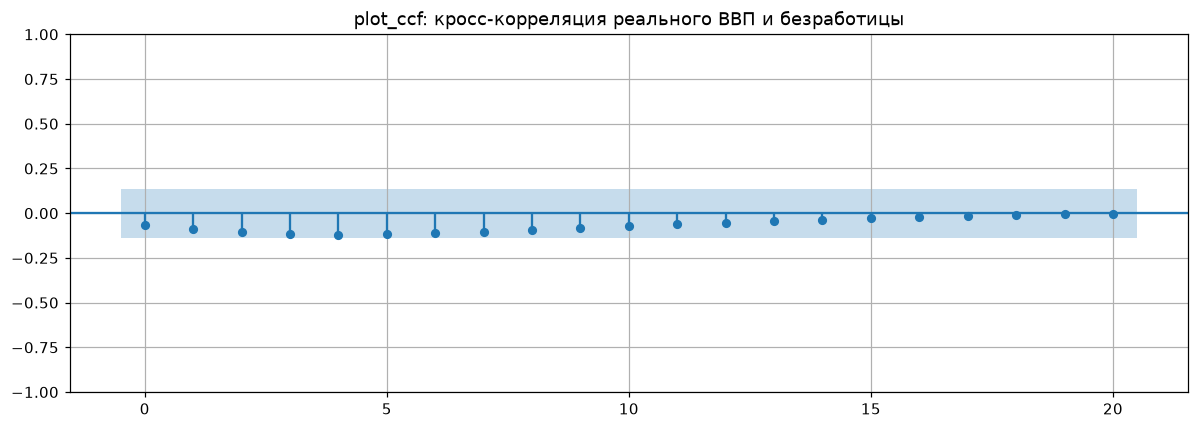

In [31]:
# CCF: корреляция ВВП и безработицы при разных сдвигах между ними.
fig, ax = plt.subplots(figsize=(11, 4))
plot_ccf(
    macro["realgdp"].values,
    macro["unemp"].values,
    lags=20,
    ax=ax,
)
ax.set_title("plot_ccf: кросс-корреляция реального ВВП и безработицы")
fig.tight_layout()

`plot_accf_grid` строит сразу всю матрицу: на диагонали — ACF каждого ряда,
вне диагонали — кросс-корреляции между парами. Удобный первый взгляд на
многомерный ряд.

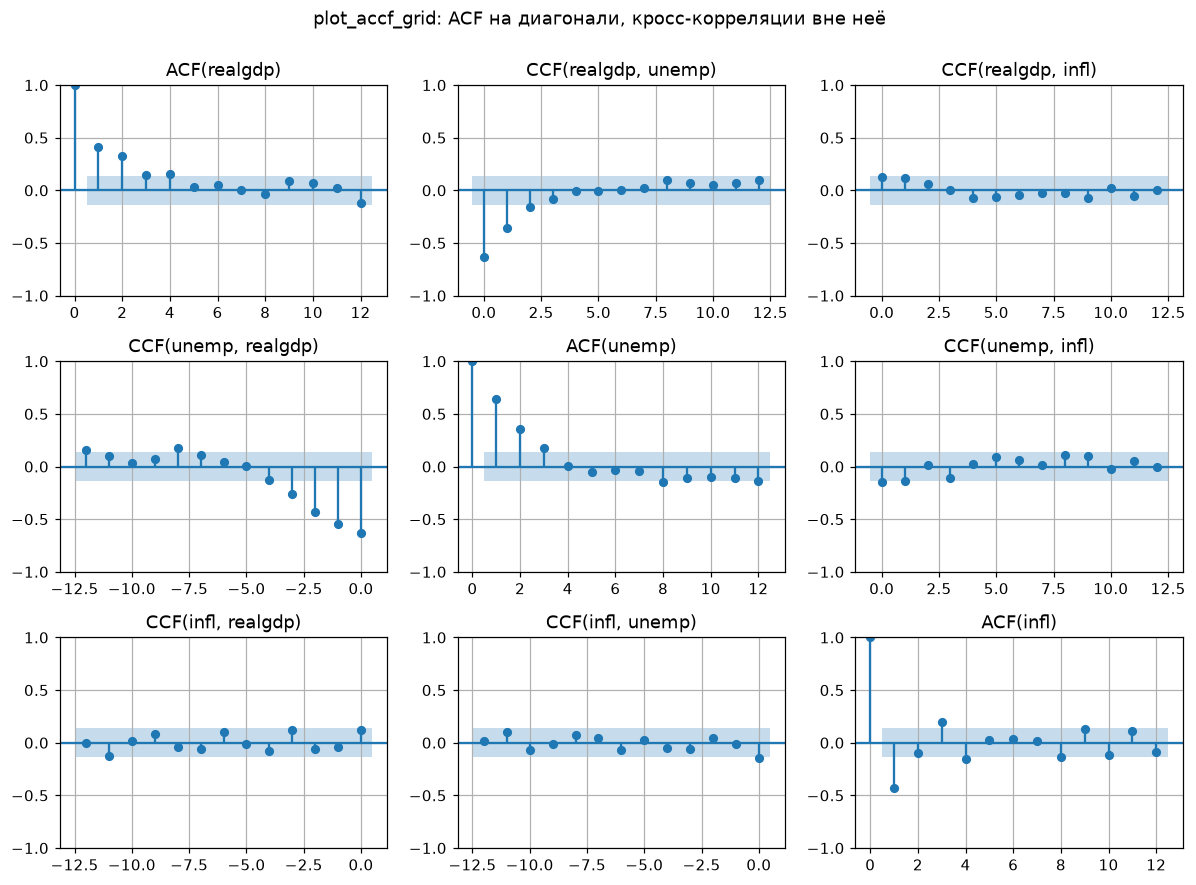

In [32]:
# Берём три показателя и смотрим все их взаимосвязи одной картинкой.
# Работаем с приростами (diff), иначе общий тренд «зашумит» все корреляции.
subset = macro[["realgdp", "unemp", "infl"]].diff().dropna()

fig = plot_accf_grid(subset.values, varnames=list(subset.columns), lags=12)
fig.set_size_inches(11, 8)
fig.suptitle("plot_accf_grid: ACF на диагонали, кросс-корреляции вне неё", y=1.00)
fig.tight_layout()

---
# Итоги

## Что важно запомнить

**0. Концепция.** `statsmodels` — библиотека статистического анализа. Интерфейс
почти всегда трёхшаговый: `Model(...)` → `.fit()` → объект результатов.
Результат `.fit()` нужно сохранять. Терминология: `endog` — то, что моделируем,
`exog` — внешние регрессоры.

**1. Формат данных.** Никаких своих контейнеров: `pd.Series` для одного ряда,
`pd.DataFrame` для нескольких. Индекс — `DatetimeIndex`/`PeriodIndex` **с заданным
`freq`**. Отсутствие `freq` — источник самых частых ошибок; лечится `.asfreq()`.
Пропуски интерполируем, а не удаляем.

**2. Визуализация и анализ.**

| Вопрос | Инструмент |
|---|---|
| как ряд себя ведёт | обычный график `.plot()` |
| есть ли память о прошлом | `acf`/`pacf`, `plot_acf`/`plot_pacf` |
| есть ли сезонность, где пик | `month_plot`, `quarter_plot`, `seasonal_plot` |
| из чего состоит ряд | `seasonal_decompose`, `STL` + `.plot()` |
| стационарен ли ряд | `adfuller`, `kpss` (гипотезы зеркальные!) |
| связаны ли ряды | `plot_ccf`, `plot_accf_grid` |

**Ориентир для чтения ACF:** белый шум = всё внутри синей полосы; тренд = медленное
затухание; сезонность = пики на кратных лагах.

## Что дальше

* **Преобразования ряда** — логарифм и Box–Cox, дифференцирование, лаги как признаки,
  детренд, фильтры. Как из нестационарного ряда сделать пригодный для модели.
* **Модели и прогнозы** — и вместе с ними диагностика: `plot_predict`,
  `plot_diagnostics`, анализ остатков.

Оба сюжета есть в ноутбуке `Черновик — преобразования и диагностика.ipynb`.

## Место `statsmodels` среди других библиотек

| Библиотека | Формат данных | Сильная сторона |
|---|---|---|
| **statsmodels** | `pd.Series` / `pd.DataFrame` + `freq` | статистика, тесты, диагностика, интерпретируемость |
| **sktime** | `pd.DataFrame` с MultiIndex | единый API в стиле `scikit-learn`, пайплайны |
| **ETNA** | свой `TSDataset` | промышленные пайплайны, работа с множеством рядов |
| **StatsForecast** | «длинный» формат: `unique_id`, `ds`, `y` | скорость на тысячах рядов |
| **Darts** | свой `TimeSeries` | нейросетевые модели |

Именно поэтому `statsmodels` остаётся базовой библиотекой курса: она даёт понимание
того, **что** мы делаем с рядом. Остальные библиотеки решают вопрос,
**как** делать это удобно и в больших масштабах.

---
# Задания для самостоятельной работы

Данные лежат в папке `../data/`. Для каждого задания есть подсказка о том,
какой инструмент из ноутбука пригодится.

**Задание 1 (формат данных).** Загрузите `../data/monthly-car-sales.csv`.
Даты в нём записаны как `1960-01` — проверьте, что `parse_dates` справляется.
Приведите ряд к `Series` с `freq='MS'` и убедитесь с помощью функции `check_ts`,
что он готов к анализу.

**Задание 2 (автокорреляция).** Для ряда продаж автомобилей постройте `plot_acf`
на 36 лагов. На каких лагах столбики выходят за синюю полосу? Определите период
сезонности по расположению пиков и сверьтесь с числами из `acf(..., nlags=26)`.

**Задание 3 (сезонность и разложение).** Постройте `month_plot` для продаж
автомобилей. В каком месяце пик продаж? Растёт ли сезонная амплитуда со временем —
и какую модель разложения (аддитивную или мультипликативную) это подсказывает?
Проверьте догадку: постройте `seasonal_decompose` с обоими значениями `model=`
и сравните остатки — у более подходящей модели остаток больше похож на шум
(меньше видимой структуры на графике `.plot()`).

**Задание 4 (проверка гипотезы).** Загрузите `../data/daily-total-female-births.csv`
(дневные данные, столбец с датой — `Date`). Постройте ACF и проверьте гипотезу
о недельной сезонности: видны ли выраженные пики на лагах 7, 14, 21?
Подсказка: для дневных данных `freq='D'`. Учтите, что ответ «сезонности нет» —
такой же полноценный результат анализа, как и «сезонность есть»; важно уметь
обосновать его границами значимости на графике.

**Задание 5 (стационарность).** Примените `stationarity_report` к трём рядам:
продажам автомобилей, рождаемости из задания 4 и числу солнечных пятен
(`sm.datasets.sunspots`, столбец `SUNACTIVITY` — годовые данные, `freq='YS'`).
Где тесты согласны, а где расходятся? Сопоставьте вердикт с видом графика ряда.

**Задание 6\* (многомерный случай).** Из датасета `macrodata` возьмите
`realgdp`, `realcons` и `cpi`. Постройте `plot_accf_grid` для их приростов.
Какая пара показателей связана сильнее всего?